# Antarctic-Penguin-Species-Classification-Neural-Network

## Instalación de librerias 

In [12]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Cargar datos y limpieza de datos nulos 


* `import...`: Traemos todas las herramientas necesarias.
* `sns.load_dataset("penguins").dropna()`: Obtenemos los datos. El `dropna()` es vital aquí porque, a diferencia de los píxeles de MNIST, en los datos biológicos reales a veces faltan mediciones (filas vacías) y la red fallaría si encuentra un valor "NaN".
* `X = ...`: Seleccionamos las 4 columnas de entrada (nuestras dimensiones).
* `LabelEncoder()`: Como la red solo entiende números, esto traduce automáticamente "Adelie" en `0`, "Chinstrap" en `1`, etc.
* `train_test_split(...)`: Separamos el 20% de los datos para que funcionen como un "examen sorpresa" para el modelo.

In [13]:
# 1. Cargar datos y limpiar valores nulos
df = sns.load_dataset("penguins").dropna()

# 2. Definir características (X) y objetivo (y)
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

# 3. Convertir nombres de especies a números (Adelie=0, Chinstrap=1, Gentoo=2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# 4. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"¡Datos listos! Tenemos {X_train.shape[0]} pingüinos para entrenar.")
print(f"Especies a clasificar: {list(encoder.classes_)}")

¡Datos listos! Tenemos 266 pingüinos para entrenar.
Especies a clasificar: ['Adelie', 'Chinstrap', 'Gentoo']


### Estandarización de Variables Mediante Z-Score

### Z-Score

Entender el **Z-score** es fundamental, especialmente con tu formación en biología, donde las escalas de medición pueden variar drásticamente entre una ballena y un pingüino. Aquí tienes el desglose técnico de por qué es el "traductor universal" de nuestra red neuronal.

#### ¿Qué es el Z-score?

El **Z-score** (o puntaje estándar) es una medida que nos dice a cuántas **desviaciones estándar** se encuentra un dato específico del promedio de su grupo.

Matemáticamente, se define con la siguiente fórmula:

$$Z = \frac{x - \mu}{\sigma}$$

Donde:

* $x$ : Es el valor original (ej. 5000g de masa corporal).
* $\mu$ : Es el promedio (media) de todos los datos de esa columna.
* $\sigma$: Es la desviación estándar (qué tanto se dispersan los datos).

#### ¿Es una prueba estadística?

Más que una prueba en sí (como un t-test o ANOVA), el Z-score es una **transformación estadística**. Se basa en la **Distribución Normal** (o Campana de Gauss).

Al aplicar esta fórmula a todos nuestros datos, realizamos un proceso llamado **Estandarización**. Esto convierte cualquier conjunto de datos en una **Distribución Normal Estándar**, donde:

1. La **media** siempre es **0**.
2. La **desviación estándar** siempre es **1**.

#### Objetivo en la Red Neuronal

En una red neuronal, el Z-score tiene tres misiones críticas:

1. **Eliminar la "Tiranía de las Magnitudes":** Si un pingüino pesa **5000g** y su pico mide **40mm**, la red neuronal (que es pura matemática) pensará que el peso es mucho más importante solo porque el número es más grande. El Z-score pone a ambos en el mismo "idioma" (por ejemplo, el peso podría ser  y el pico ).
2. **Acelerar el Aprendizaje (Convergencia):** El optimizador (como Adam) viaja por un "paisaje matemático" buscando el error más bajo. Si los datos no están escalados, ese paisaje es un valle estrecho y deformado donde es fácil perderse. Con el Z-score, el valle es redondo y simétrico, permitiendo que la red aprenda mucho más rápido.
3. **Estabilidad de los Gradientes:** Evita que los números en las multiplicaciones internas de la red se disparen a infinito o se reduzcan a cero absoluto, manteniendo la salud de nuestras neuronas durante el entrenamiento.

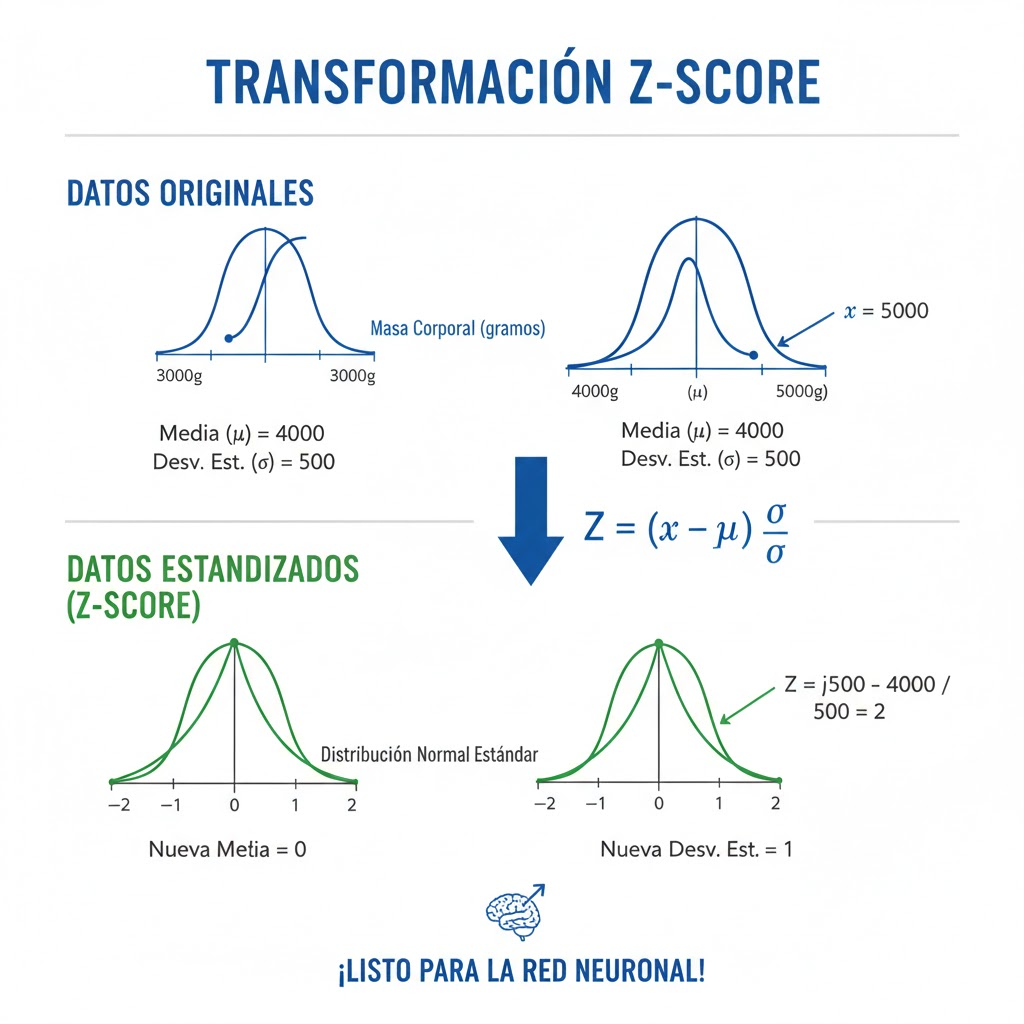

In [14]:
# 1. Crear el escalador profesional (StandardScaler aplica la fórmula del Z-score)
scaler = StandardScaler()

# 2. Ajustar el escalador con los datos de entrenamiento y transformar ambos conjuntos
# fit_transform calcula la media y desviación estándar de X_train y las aplica
X_train_scaled = scaler.fit_transform(X_train)

# transform usa los valores calculados en el paso anterior para escalar X_test
X_test_scaled = scaler.transform(X_test)

# 3. Verificar la transformación del primer pingüino
print("Medidas originales del primer pingüino:\n", X_train.iloc[0].values)
print("\nMedidas tras Z-Score (X_train_scaled):\n", X_train_scaled[0])

Medidas originales del primer pingüino:
 [  40.9   13.7  214.  4650. ]

Medidas tras Z-Score (X_train_scaled):
 [-0.59372706 -1.75093934  0.9359428   0.53973681]


### Creacion de la Arquitectura de la Red Neuronal

#### Librerias 

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-02-21 22:27:47.020412: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-21 22:27:47.194327: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 22:27:51.899336: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [1]:
# Definimos la estructura del modelo
modelo_pingüinos = Sequential([
    # Capa de entrada con 4 neuronas (una por cada medida biológica)
    # Capa oculta con 32 neuronas y activación ReLU
    Dense(32, activation='relu', input_shape=(4,)),
    
    # Segunda capa oculta para captar relaciones complejas
    Dense(16, activation='relu'),
    
    # Capa de salida con 3 neuronas (una por cada especie)
    # Usamos Softmax para obtener porcentajes de probabilidad
    Dense(3, activation='softmax')
])

# Resumen de la arquitectura
modelo_pingüinos.summary()

NameError: name 'Sequential' is not defined